# Introduction

## Lab2: Train a Convolutional Neural Network (CNN).

In this Lab session we will learn how to train a CNN from scratch for classifying MNIST digits.

NOTE: All text cells starting with a number indicate that you have to write code or write a response. However, read all the cells to understand the full pipeline.

IMPORTANT: The goal is for you to learn how CNNs are implemented and trained with Pytorch. Using AI to write code for you harms this learning process, so it is strictly forbidden to use AI to write code. Feel free to use AI to _learn_ about Pytorch, CNNs, etc., but you are highly encouraged to read Pytorch's very good documentation, too. Concepts you learn in this assignment will be relevant for the exam.

In [1]:
# import necessary libraries
import torch
import torchvision
from torchvision import transforms as T
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

### 1. Define LeNet

![network architecture](https://www.researchgate.net/profile/Lucijano-Berus/publication/329891470/figure/fig1/AS:707347647307776@1545656229128/Architecture-of-LeNet-5-a-Convolutional-Neural-Network-for-digits-digits-recognition-An.ppm)

Here we are going to define our first CNN which is **LeNet** in this case. This architecture has been introduced and is detailed in [this article](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf). To construct a LeNet we will be using two convolutional layers followed by three fully-connected layers as indicated in the figure. The convolutional layers can be defined using `torch.nn.Conv2d` module of `torch.nn` package. Details can be found [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Moreover, we will use a pooling operation to reduce the size of convolutional feature maps. For this case we are going to use `torch.nn.functional.max_pool2d`. Details about maxpooling can be found [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.max_pool2d.html)

Differently from our previous Lab, we will use a Rectified Linear Units (ReLU) as activation function with the help of `torch.nn.functional.relu`, replacing `torch.nn.Sigmoid`. Details about ReLU can be found [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.relu.html).

Note: The figure shows 32x32 input size while your data will be slightly differnt. You can either pad the input or adjust the network architecture slightly (as little as possible).

In [ ]:
class LeNet(torch.nn.Module):
  def __init__(self):
    super(LeNet, self).__init__()
    
    self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
    self.conv2 = torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)

    self.fc1 = torch.nn.Linear(16 * 5 * 5, 120)
    self.fc2 = torch.nn.Linear(120, 84)
    self.fc3 = torch.nn.Linear(84, 10)

  def forward(self, x):
    x = F.relu(self.conv1(x)) 
    x = F.max_pool2d(x, kernel_size=2) 

    x = F.relu(self.conv2(x))  
    x = F.max_pool2d(x, kernel_size=2) 

    x = x.view(x.shape[0], -1)

    x = F.relu(self.fc1(x))  

    x = F.relu(self.fc2(x)) 

    x = self.fc3(x)

    return x

### 2. Define cost function
Hint: Make sure to read the documentation of the loss function you use to validate that your network output matches what the loss expects as input.

In [ ]:
def get_cost_function():
  cost_function = torch.nn.CrossEntropyLoss()
  return cost_function

### 3. Define the optimizer

We will use SGD with learning rate-lr, weight_decay=wd and  momentum=momentum

In [4]:
def get_optimizer(net, lr, wd, momentum):
  optimizer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd, momentum=momentum)
  return optimizer

### Train and test functions

In [5]:
def test(net, data_loader, cost_function, device='cuda:0'):
  samples = 0.
  cumulative_loss = 0.
  cumulative_accuracy = 0.

  net.eval() # Strictly needed if network contains layers which has different behaviours between train and test
  with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(data_loader):
      # Load data into GPU
      inputs = inputs.to(device)
      targets = targets.to(device)

      # Forward pass
      outputs = net(inputs)

      # Apply the loss
      loss = cost_function(outputs, targets)

      # Better print something
      samples+=inputs.shape[0]
      cumulative_loss += loss.item() # Note: the .item() is needed to extract scalars from tensors
      _, predicted = outputs.max(1)
      cumulative_accuracy += predicted.eq(targets).sum().item()

  return cumulative_loss/samples, cumulative_accuracy/samples*100


def train(net,data_loader,optimizer,cost_function, device='cuda:0'):
  samples = 0.
  cumulative_loss = 0.
  cumulative_accuracy = 0.


  net.train() # Strictly needed if network contains layers which has different behaviours between train and test
  for batch_idx, (inputs, targets) in enumerate(data_loader):
    # Load data into GPU
    inputs = inputs.to(device)
    targets = targets.to(device)

    # Forward pass
    outputs = net(inputs)

    # Apply the loss
    loss = cost_function(outputs,targets)

    # Reset the optimizer
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update parameters
    optimizer.step()

    # Better print something, no?
    samples+=inputs.shape[0]
    cumulative_loss += loss.item()
    _, predicted = outputs.max(1)
    cumulative_accuracy += predicted.eq(targets).sum().item()

  return cumulative_loss/samples, cumulative_accuracy/samples*100

### Define the function that fetches a data loader that is then used during iterative training.

We will learn a new thing in this function as how to Normalize the inputs given to the network.

***Why Normalization is needed***?

To have nice and stable training of the network it is recommended to normalize the network inputs between \[-1, 1\].

***How it can be done***?

This can be simply done using `torchvision.transforms.Normalize()` transform. Details can be found [here](https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.Normalize.html).

In [6]:
def get_data(batch_size, test_batch_size=256, dataset='mnist', augment=False):

  if dataset == 'mnist':
    # Prepare data transformations and then combine them sequentially
    transform = list()
    transform.append(T.ToTensor())                            # converts Numpy to Pytorch Tensor
    transform.append(T.Normalize(mean=[0.5], std=[0.5]))      # Normalizes the Tensors between [-1, 1]
    transform = T.Compose(transform)                          # Composes the above transformations into one.

    # Load data
    full_training_data = torchvision.datasets.MNIST('./data', train=True, transform=transform, download=True)
    test_data = torchvision.datasets.MNIST('./data', train=False, transform=transform, download=True)

  elif dataset == 'cifar10':
    # Data augmentation transforms (only for training)
    if augment:
      train_transform = T.Compose([
        T.RandomHorizontalFlip(),
        T.RandomCrop(32, padding=4),
        T.ColorJitter(brightness=0.2, contrast=0.2),
        T.ToTensor(),
        T.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
      ])
    else:
      train_transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
      ])

    test_transform = T.Compose([
      T.ToTensor(),
      T.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
    ])

    full_training_data = torchvision.datasets.CIFAR10('./data', train=True, transform=train_transform, download=True)
    test_data = torchvision.datasets.CIFAR10('./data', train=False, transform=test_transform, download=True)

  # Create train and validation splits
  num_samples = len(full_training_data)
  training_samples = int(num_samples*0.5+1)
  validation_samples = num_samples - training_samples

  training_data, validation_data = torch.utils.data.random_split(full_training_data, [training_samples, validation_samples])

  # Initialize dataloaders
  train_loader = torch.utils.data.DataLoader(training_data, batch_size, shuffle=True)
  val_loader = torch.utils.data.DataLoader(validation_data, test_batch_size, shuffle=False)
  test_loader = torch.utils.data.DataLoader(test_data, test_batch_size, shuffle=False)

  return train_loader, val_loader, test_loader

### 4. Initializing model and wrapping everything up

Finally, we need a main function which initializes everything + the needed hyperparameters and loops over multiple epochs (printing the results).

In [7]:
'''
Input arguments
  batch_size: Size of a mini-batch
  device: GPU where you want to train your network
  weight_decay: Weight decay co-efficient for regularization of weights
  momentum: Momentum for SGD optimizer
  epochs: Number of epochs for training the network
  early_stopping_patience: if > 0, stop training if val loss does not improve for this many epochs
  use_sequential: if True, use the Sequential API version of LeNet
  dataset: 'mnist' or 'cifar10'
  augment: if True, use data augmentation (for CIFAR10)
  use_dropout: if True, add dropout layers in the network
  use_resnet: if True, use ResNet18 instead of LeNet
'''

def main(batch_size=128,
         device='cuda:0',
         learning_rate=0.01,
         weight_decay=0.000001,
         momentum=0.9,
         epochs=50,
         early_stopping_patience=0,
         use_sequential=False,
         dataset='mnist',
         augment=False,
         use_dropout=False,
         use_resnet=False):

  train_loader, val_loader, test_loader = get_data(batch_size, dataset=dataset, augment=augment)

  # Define the network and move it to the GPU
  if use_resnet:
    # Task 10: Use ResNet18 from torchvision
    net = torchvision.models.resnet18(weights=None)
    # Adapt the first conv layer for CIFAR10 (32x32 images, 3 channels)
    net.conv1 = torch.nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    net.maxpool = torch.nn.Identity()  # Remove the initial maxpool for small images
    net.fc = torch.nn.Linear(512, 10)  # 10 classes for CIFAR10
  elif use_sequential:
    # Task 6: Sequential API version
    net = LeNetSequential(use_dropout=use_dropout, dataset=dataset)
  else:
    # Task 1-5: Standard LeNet
    if use_dropout:
      net = LeNetDropout(dataset=dataset)
    else:
      net = LeNet() if dataset == 'mnist' else LeNetCIFAR()

  net = net.to(device)

  optimizer = get_optimizer(net, learning_rate, weight_decay, momentum)

  cost_function = get_cost_function()

  print('Before training:')
  train_loss, train_accuracy = test(net, train_loader, cost_function, device)
  val_loss, val_accuracy = test(net, val_loader, cost_function, device)
  test_loss, test_accuracy = test(net, test_loader, cost_function, device)

  print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
  print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
  print('\t Test loss {:.5f}, Test accuracy {:.2f}'.format(test_loss, test_accuracy))
  print('-----------------------------------------------------')

  # Lists for plotting (optional task)
  train_losses, train_accuracies = [], []
  val_losses, val_accuracies = [], []

  # Early stopping variables
  best_val_loss = float('inf')
  epochs_no_improve = 0
  best_model_state = None

  for e in range(epochs):
    train_loss, train_accuracy = train(net, train_loader, optimizer, cost_function, device)
    val_loss, val_accuracy = test(net, val_loader, cost_function, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print('Epoch: {:d}'.format(e+1))
    print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
    print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
    print('-----------------------------------------------------')

    # Task 7: Early stopping
    if early_stopping_patience > 0:
      if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Optional: save best model weights
        import copy
        best_model_state = copy.deepcopy(net.state_dict())
      else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
          print(f'Early stopping triggered after {e+1} epochs (no improvement for {early_stopping_patience} consecutive epochs).')
          break

  # Optional: restore best model
  if early_stopping_patience > 0 and best_model_state is not None:
    net.load_state_dict(best_model_state)
    print('Restored best model (lowest validation loss).')

  print('After training:')
  train_loss, train_accuracy = test(net, train_loader, cost_function, device)
  val_loss, val_accuracy = test(net, val_loader, cost_function, device)
  test_loss, test_accuracy = test(net, test_loader, cost_function, device)

  print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
  print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
  print('\t Test loss {:.5f}, Test accuracy {:.2f}'.format(test_loss, test_accuracy))
  print('-----------------------------------------------------')

  return net, train_losses, train_accuracies, val_losses, val_accuracies, test_loader, cost_function, device

Lets train!

In [8]:
# Detect available device (use GPU if available, otherwise CPU)
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

net, train_losses, train_accuracies, val_losses, val_accuracies, test_loader, cost_function, device = main(device=device)

Using device: cpu
Before training:
	 Training loss 0.01804, Training accuracy 9.99
	 Validation loss 0.00906, Validation accuracy 9.68
	 Test loss 0.00922, Test accuracy 9.70
-----------------------------------------------------
Epoch: 1
	 Training loss 0.00847, Training accuracy 66.47
	 Validation loss 0.00071, Validation accuracy 94.67
-----------------------------------------------------
Epoch: 2
	 Training loss 0.00098, Training accuracy 96.12
	 Validation loss 0.00048, Validation accuracy 96.44
-----------------------------------------------------
Epoch: 3
	 Training loss 0.00069, Training accuracy 97.23
	 Validation loss 0.00042, Validation accuracy 96.78
-----------------------------------------------------
Epoch: 4
	 Training loss 0.00055, Training accuracy 97.72
	 Validation loss 0.00042, Validation accuracy 96.69
-----------------------------------------------------
Epoch: 5
	 Training loss 0.00046, Training accuracy 98.10
	 Validation loss 0.00027, Validation accuracy 98.00


#### Optional: Plot the training and validation curves.



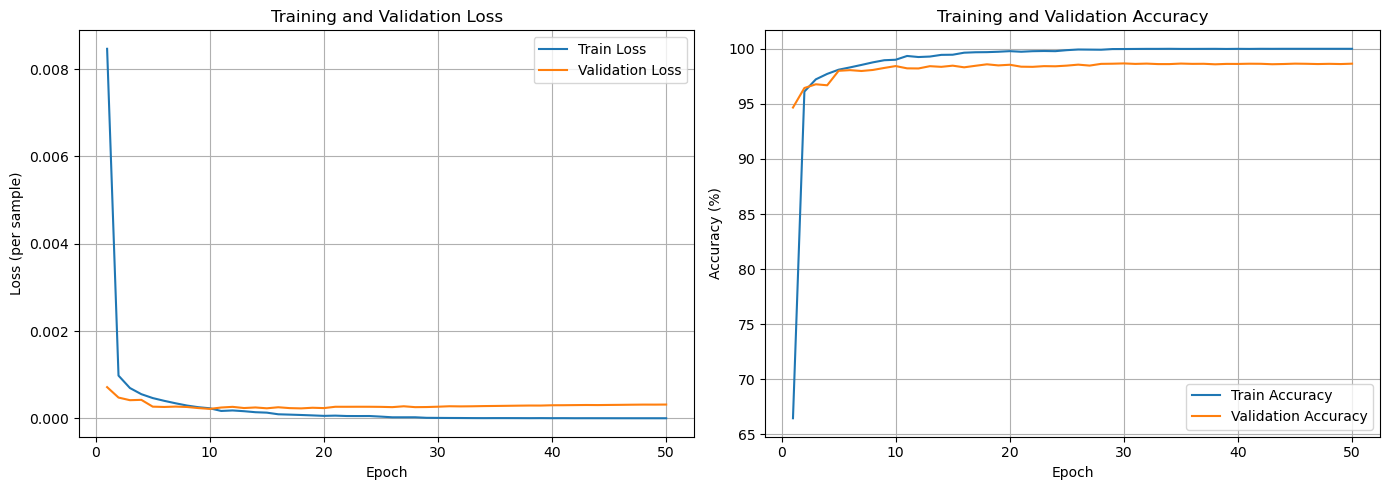

In [9]:
# Plot training and validation loss/accuracy curves
epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(epochs_range, train_losses, label='Train Loss')
axes[0].plot(epochs_range, val_losses, label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (per sample)')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy curves
axes[1].plot(epochs_range, train_accuracies, label='Train Accuracy')
axes[1].plot(epochs_range, val_accuracies, label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 5. Plot a confusion matrix to check which MNIST digit is most frequently confused with which other digit. Can you explain why?



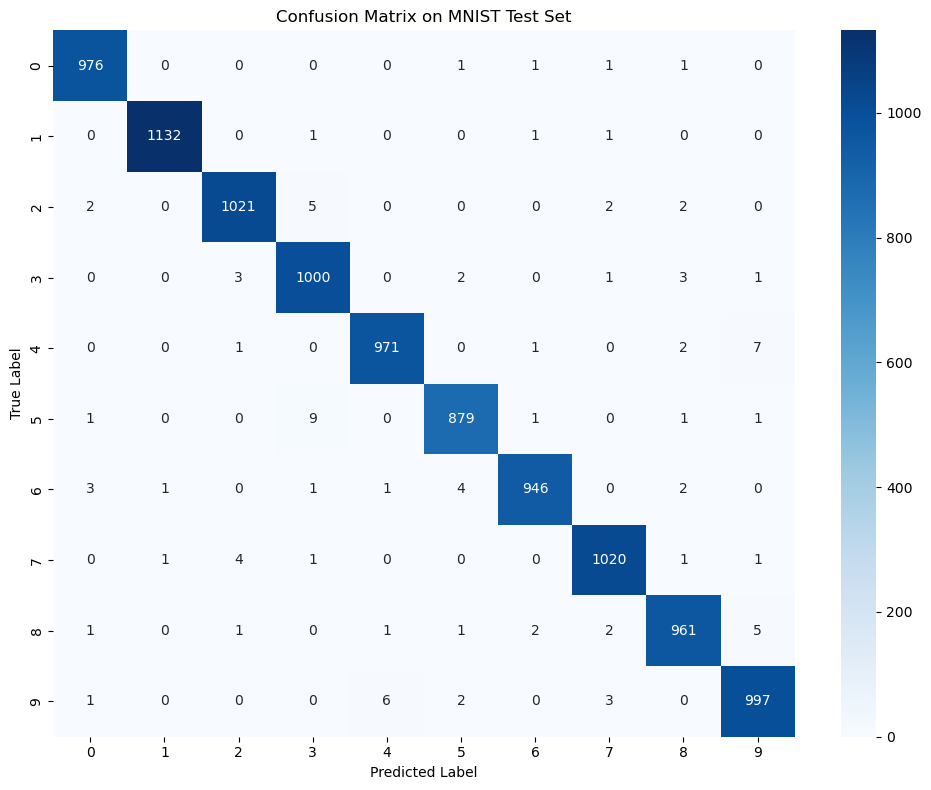

In [ ]:

net.eval()
all_preds = []
all_targets = []

with torch.no_grad():
  for inputs, targets in test_loader:
    inputs = inputs.to(device)
    outputs = net(inputs)
    _, predicted = outputs.max(1)
    all_preds.extend(predicted.cpu().numpy())
    all_targets.extend(targets.numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Plot it
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(range(10)),
            yticklabels=list(range(10)))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on MNIST Test Set')
plt.tight_layout()
plt.show()



### For the remaining tasks try to integrate the changes in the code above while avoiding duplicate code as much as possible. For every task, introduce flags (i.e., function arguments) to the main() function to enable the new functionality of the task. It should always be possible to run the original implementation above. Finally, call the main function with the correct flags for each task in the cells below.

### 6. The LeNet5 architecture can also be implemented using the sequential API ([see documentation](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)). Reimplement it with this API and run training + evaluation once to verify it works.

In [ ]:
class LeNetSequential(torch.nn.Module):
  """
  LeNet-5 reimplemented with torch.nn.Sequential.
  Supports both MNIST (1 channel) and CIFAR10 (3 channels) via the dataset flag.
  """
  def __init__(self, use_dropout=False, dataset='mnist'):
    super(LeNetSequential, self).__init__()

    in_channels = 1 if dataset == 'mnist' else 3
    dropout_p = 0.5 if use_dropout else 0.0

    self.features = torch.nn.Sequential(
      torch.nn.Conv2d(in_channels=in_channels, out_channels=6, kernel_size=5, padding=2),
      torch.nn.ReLU(),
      torch.nn.MaxPool2d(kernel_size=2),
      torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
      torch.nn.ReLU(),
      torch.nn.MaxPool2d(kernel_size=2),
    )

    
    fc_in = 16 * 5 * 5 if dataset == 'mnist' else 16 * 6 * 6

    classifier_layers = [
      torch.nn.Linear(fc_in, 120),
      torch.nn.ReLU(),
    ]
    if use_dropout:
      classifier_layers.append(torch.nn.Dropout(p=dropout_p))
    classifier_layers += [
      torch.nn.Linear(120, 84),
      torch.nn.ReLU(),
    ]
    if use_dropout:
      classifier_layers.append(torch.nn.Dropout(p=dropout_p))
    classifier_layers.append(torch.nn.Linear(84, 10))

    self.classifier = torch.nn.Sequential(*classifier_layers)

  def forward(self, x):
    x = self.features(x)
    x = x.view(x.shape[0], -1)   
    x = self.classifier(x)
    return x



device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('=== Task 6: LeNet Sequential ===')
main(device=device, use_sequential=True, epochs=5)  

=== Task 6: LeNet Sequential ===
Before training:
	 Training loss 0.01805, Training accuracy 8.66
	 Validation loss 0.00906, Validation accuracy 8.40
	 Test loss 0.00922, Test accuracy 8.89
-----------------------------------------------------
Epoch: 1
	 Training loss 0.00964, Training accuracy 60.09
	 Validation loss 0.00087, Validation accuracy 93.36
-----------------------------------------------------
Epoch: 2
	 Training loss 0.00117, Training accuracy 95.44
	 Validation loss 0.00045, Validation accuracy 96.47
-----------------------------------------------------
Epoch: 3
	 Training loss 0.00075, Training accuracy 97.06
	 Validation loss 0.00035, Validation accuracy 97.18
-----------------------------------------------------
Epoch: 4
	 Training loss 0.00054, Training accuracy 97.83
	 Validation loss 0.00025, Validation accuracy 98.01
-----------------------------------------------------
Epoch: 5
	 Training loss 0.00046, Training accuracy 98.20
	 Validation loss 0.00024, Validation 

(LeNetSequential(
   (features): Sequential(
     (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
     (1): ReLU()
     (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
     (4): ReLU()
     (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (classifier): Sequential(
     (0): Linear(in_features=400, out_features=120, bias=True)
     (1): ReLU()
     (2): Linear(in_features=120, out_features=84, bias=True)
     (3): ReLU()
     (4): Linear(in_features=84, out_features=10, bias=True)
   )
 ),
 [0.009637356441943455,
  0.0011699856587209041,
  0.0007485965060884168,
  0.00054495575127557,
  0.0004551710762169954],
 [60.0946635112163,
  95.43681877270758,
  97.06009799673345,
  97.83340555314824,
  98.20005999800007],
 [0.0008702357260043345,
  0.00044611470003959205,
  0.0003535059614149172,
  0.0002545575945680311,
  0.00023727370381664248],

### 7. Implement adaptive early stopping: if the validation loss did not decrease for K consecutive epochs, stop training.
#### Optional: Select the model based on the best validation loss.

In [ ]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('=== Task 7: Early Stopping (K=5) ===')
main(device=device, epochs=50, early_stopping_patience=5)

=== Task 7: Early Stopping (K=5) ===
Before training:
	 Training loss 0.01808, Training accuracy 8.96
	 Validation loss 0.00908, Validation accuracy 9.48
	 Test loss 0.00923, Test accuracy 8.56
-----------------------------------------------------
Epoch: 1
	 Training loss 0.01078, Training accuracy 57.10
	 Validation loss 0.00095, Validation accuracy 92.37
-----------------------------------------------------
Epoch: 2
	 Training loss 0.00128, Training accuracy 94.96
	 Validation loss 0.00048, Validation accuracy 96.29
-----------------------------------------------------
Epoch: 3
	 Training loss 0.00080, Training accuracy 96.73
	 Validation loss 0.00033, Validation accuracy 97.38
-----------------------------------------------------
Epoch: 4
	 Training loss 0.00058, Training accuracy 97.68
	 Validation loss 0.00029, Validation accuracy 97.74
-----------------------------------------------------
Epoch: 5
	 Training loss 0.00045, Training accuracy 98.17
	 Validation loss 0.00027, Validat

(LeNet(
   (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
   (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
   (fc1): Linear(in_features=400, out_features=120, bias=True)
   (fc2): Linear(in_features=120, out_features=84, bias=True)
   (fc3): Linear(in_features=84, out_features=10, bias=True)
 ),
 [0.01078047821936673,
  0.0012757952660714573,
  0.0008003650045525328,
  0.000576086409015221,
  0.0004536843830441134,
  0.0003806201490178376,
  0.0003341071926098812,
  0.0002838784128776802,
  0.00024892594992172255,
  0.00021252112190496572,
  0.0001682566933799892,
  0.00017012835117286373,
  0.00015378726452455798,
  0.00013910698377142395,
  0.00011566926644714128,
  9.000005085428666e-05,
  8.594470446448199e-05,
  7.411406881388021e-05,
  6.088767029439996e-05,
  5.568197368018692e-05],
 [57.101429952334925,
  94.95683477217426,
  96.7301089963668,
  97.67674410852972,
  98.17006099796673,
  98.49671677610746,
  98.62337922069264,
  98.753374887

### 8. Change the dataset in order to train and evaluate the LeNet5 network on [CIFAR10](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html).

In [ ]:
class LeNetCIFAR(torch.nn.Module):

  def __init__(self):
    super(LeNetCIFAR, self).__init__()
    self.conv1 = torch.nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, padding=2)
    self.conv2 = torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
    self.fc1 = torch.nn.Linear(16 * 6 * 6, 120)
    self.fc2 = torch.nn.Linear(120, 84)
    self.fc3 = torch.nn.Linear(84, 10)

  def forward(self, x):
    x = F.max_pool2d(F.relu(self.conv1(x)), 2)  
    x = F.max_pool2d(F.relu(self.conv2(x)), 2)  
    x = x.view(x.shape[0], -1)                  
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x


device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('=== Task 8: LeNet on CIFAR10 ===')
main(device=device, dataset='cifar10', epochs=30)

=== Task 8: LeNet on CIFAR10 ===
Before training:
	 Training loss 0.01808, Training accuracy 8.09
	 Validation loss 0.00904, Validation accuracy 7.85
	 Test loss 0.00922, Test accuracy 7.98
-----------------------------------------------------
Epoch: 1
	 Training loss 0.01595, Training accuracy 25.15
	 Validation loss 0.00696, Validation accuracy 35.35
-----------------------------------------------------
Epoch: 2
	 Training loss 0.01229, Training accuracy 42.63
	 Validation loss 0.00571, Validation accuracy 47.08
-----------------------------------------------------
Epoch: 3
	 Training loss 0.01090, Training accuracy 49.69
	 Validation loss 0.00524, Validation accuracy 51.71
-----------------------------------------------------
Epoch: 4
	 Training loss 0.01008, Training accuracy 53.33
	 Validation loss 0.00511, Validation accuracy 53.52
-----------------------------------------------------
Epoch: 5
	 Training loss 0.00933, Training accuracy 57.67
	 Validation loss 0.00472, Validation 

(LeNetCIFAR(
   (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
   (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
   (fc1): Linear(in_features=576, out_features=120, bias=True)
   (fc2): Linear(in_features=120, out_features=84, bias=True)
   (fc3): Linear(in_features=84, out_features=10, bias=True)
 ),
 [0.015947403466623787,
  0.01229193037421478,
  0.010900689365339205,
  0.010079130526185203,
  0.009329425895706634,
  0.008646034962186565,
  0.00821468885753313,
  0.007561801922358989,
  0.0070372706608535585,
  0.0066883788743565915,
  0.006261331639973232,
  0.005730552025534793,
  0.005383636481923765,
  0.004957645400791787,
  0.004628575606077396,
  0.004084913816496275,
  0.004040999078239462,
  0.0035835781062509026,
  0.0031350446228484937,
  0.0029518203286475015,
  0.002865902909345281,
  0.0025201156269926573,
  0.002439916432487941,
  0.0023341927671283727,
  0.0024719502724560205,
  0.002136227746118732,
  0.00196828420620137,
  0.001

### 9. Try to improve the performance on CIFAR10 with both:
   *   data-augmentation
   *   dropout

In [ ]:
class LeNetDropout(torch.nn.Module):
  def __init__(self, dataset='cifar10', dropout_p=0.5):
    super(LeNetDropout, self).__init__()
    in_channels = 1 if dataset == 'mnist' else 3
    fc_in = 16 * 5 * 5 if dataset == 'mnist' else 16 * 6 * 6

    self.conv1 = torch.nn.Conv2d(in_channels, 6, kernel_size=5, padding=2)
    self.conv2 = torch.nn.Conv2d(6, 16, kernel_size=5)
    self.fc1 = torch.nn.Linear(fc_in, 120)
    self.dropout1 = torch.nn.Dropout(p=dropout_p)
    self.fc2 = torch.nn.Linear(120, 84)
    self.dropout2 = torch.nn.Dropout(p=dropout_p)
    self.fc3 = torch.nn.Linear(84, 10)

  def forward(self, x):
    x = F.max_pool2d(F.relu(self.conv1(x)), 2)
    x = F.max_pool2d(F.relu(self.conv2(x)), 2)
    x = x.view(x.shape[0], -1)
    x = self.dropout1(F.relu(self.fc1(x)))
    x = self.dropout2(F.relu(self.fc2(x)))
    x = self.fc3(x)
    return x


device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('Task 9: CIFAR10 + Data Augmentation + Dropout')
main(device=device, dataset='cifar10', augment=True, use_dropout=True, epochs=30)

=== Task 9: CIFAR10 + Data Augmentation + Dropout ===
Before training:
	 Training loss 0.01809, Training accuracy 11.09
	 Validation loss 0.00905, Validation accuracy 11.32
	 Test loss 0.00923, Test accuracy 11.70
-----------------------------------------------------
Epoch: 1
	 Training loss 0.01696, Training accuracy 16.14
	 Validation loss 0.00771, Validation accuracy 25.53
-----------------------------------------------------
Epoch: 2
	 Training loss 0.01524, Training accuracy 24.55
	 Validation loss 0.00716, Validation accuracy 30.62
-----------------------------------------------------
Epoch: 3
	 Training loss 0.01441, Training accuracy 30.17
	 Validation loss 0.00671, Validation accuracy 36.10
-----------------------------------------------------
Epoch: 4
	 Training loss 0.01377, Training accuracy 34.39
	 Validation loss 0.00635, Validation accuracy 40.41
-----------------------------------------------------
Epoch: 5
	 Training loss 0.01343, Training accuracy 37.06
	 Validation l

### 10. Use the ResNet18 class from Pytorch to train and evaluate a ResNet on CIFAR10 (make sure it works, but if it takes too long, you don't have to train until convergence).

In [ ]:


device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('=== Task 10: ResNet18 on CIFAR10 ===')
main(device=device, dataset='cifar10', use_resnet=True, epochs=10, learning_rate=0.01)